In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestRegressor

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
df.shape

(2640, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [6]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [7]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

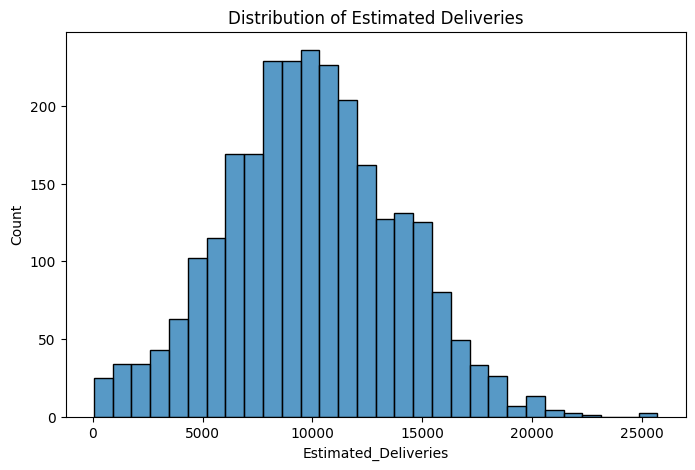

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["Estimated_Deliveries"], bins=30)
plt.title("Distribution of Estimated Deliveries")
plt.show()

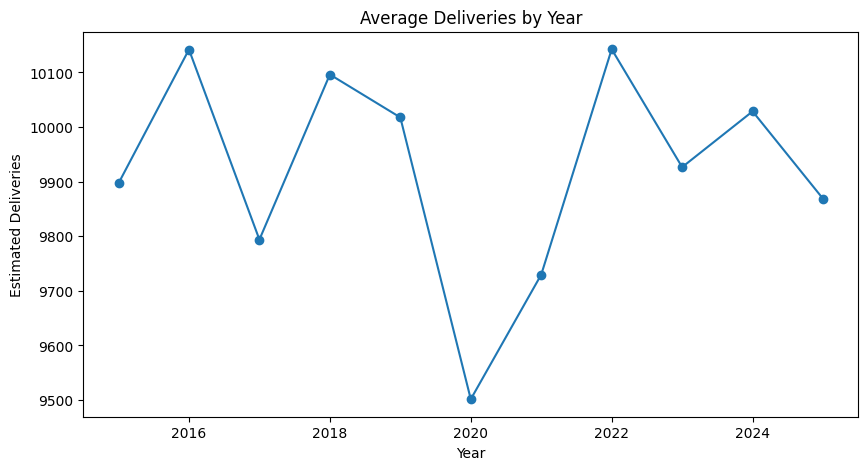

In [10]:
yearly = df.groupby("Year")["Estimated_Deliveries"].mean()

plt.figure(figsize=(10,5))
yearly.plot(marker='o')
plt.title("Average Deliveries by Year")
plt.ylabel("Estimated Deliveries")
plt.show()

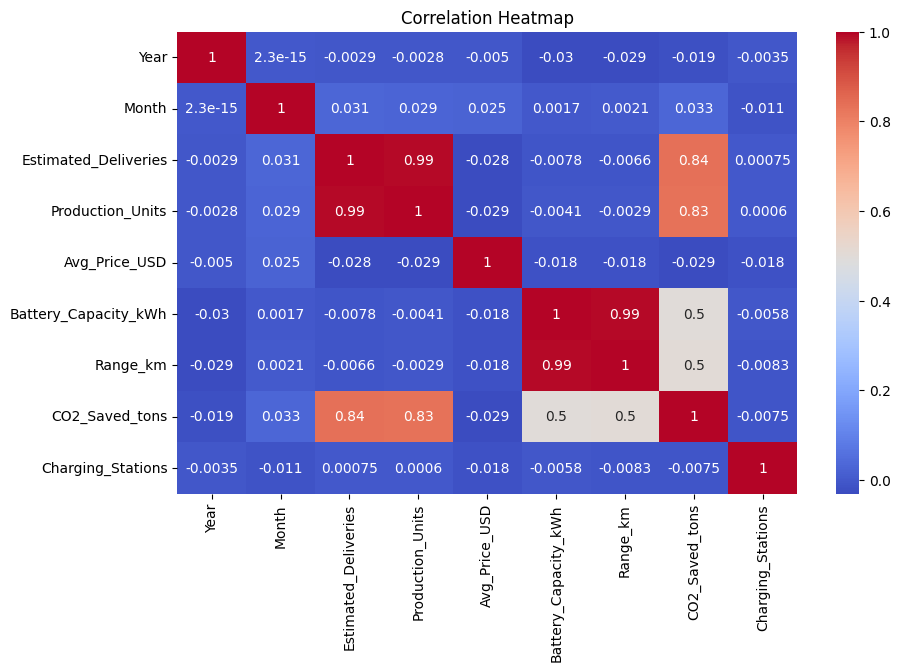

In [11]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder

le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df["Region"] = le_region.fit_transform(df["Region"])
df["Model"] = le_model.fit_transform(df["Model"])
df["Source_Type"] = le_source.fit_transform(df["Source_Type"])

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


In [13]:
X = df.drop("Estimated_Deliveries", axis=1)
y = df["Estimated_Deliveries"]

print(X.shape)
print(y.shape)

(2640, 11)
(2640,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2112, 11)
(528, 11)


In [15]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [16]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 323.46011363636364
R2 Score: 0.9887505867840798


In [17]:
print("MAE:", mae)
print("R2 Score:", r2)

MAE: 323.46011363636364
R2 Score: 0.9887505867840798


In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 100}


In [19]:
best_model = grid_search.best_estimator_

pred_tuned = best_model.predict(X_test)

print("Tuned R2:",
      r2_score(y_test, pred_tuned))

print("Tuned MAE:",
      mean_absolute_error(y_test, pred_tuned))

Tuned R2: 0.9887505867840798
Tuned MAE: 323.46011363636364


In [20]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str)
)

monthly = (
    df.groupby("Date")["Estimated_Deliveries"]
    .mean()
    .sort_index()
)

monthly.head()

Date
2015-01-01     9159.00
2015-02-01     8252.65
2015-03-01     9228.35
2015-04-01    11281.15
2015-05-01     9213.20
Name: Estimated_Deliveries, dtype: float64

In [21]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    monthly,
    order=(5,1,0)
)

arima_result = arima_model.fit()

forecast = arima_result.forecast(steps=12)

print(forecast)

2026-01-01    10114.549482
2026-02-01    10015.907223
2026-03-01     9779.714502
2026-04-01     9815.616291
2026-05-01    10016.721072
2026-06-01    10045.278093
2026-07-01     9991.806060
2026-08-01     9942.300880
2026-09-01     9916.831136
2026-10-01     9949.523312
2026-11-01     9979.088943
2026-12-01     9976.121005
Freq: MS, Name: predicted_mean, dtype: float64


/Users/tanishkajain/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/tanishkajain/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/tanishkajain/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


/var/folders/7f/99gykszs5c12khmmsg6rqtlm0000gn/T/ipykernel_32881/3117885140.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


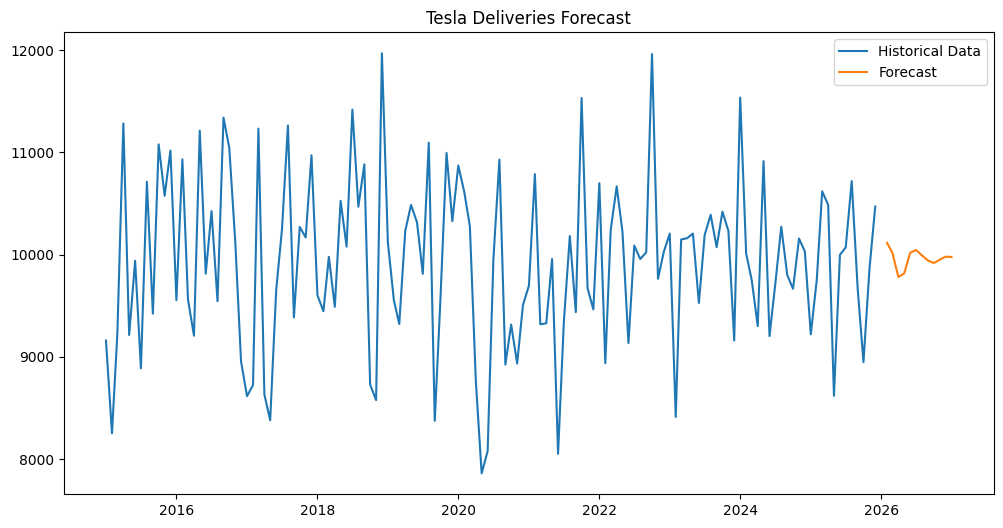

In [22]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly.index,
    monthly.values,
    label="Historical Data"
)

future_dates = pd.date_range(
    start=monthly.index[-1],
    periods=13,
    freq="M"
)[1:]

plt.plot(
    future_dates,
    forecast,
    label="Forecast"
)

plt.title("Tesla Deliveries Forecast")
plt.legend()
plt.show()

In [23]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("model",
     RandomForestRegressor(
         random_state=42
     ))
])

pipeline.fit(X_train, y_train)

print("Pipeline Created Successfully")

Pipeline Created Successfully


## EDA Observations

1. The dataset contains 2640 records and 12 features.
2. No missing values were found.
3. Estimated deliveries are approximately normally distributed.
4. Production Units have a very strong positive correlation (0.99) with Estimated Deliveries.
5. Battery Capacity and Range have a strong positive correlation (0.99).
6. CO2 Saved is positively correlated with Deliveries and Production.

## Model Evaluation

Random Forest Regressor was used to predict Tesla Estimated Deliveries.

Results:
- MAE: 323.46
- R² Score: 0.9888

The model explains approximately 98.88% of the variance in delivery values and demonstrates excellent predictive performance.

## Forecasting Results

ARIMA was applied to historical delivery data.

The forecast indicates relatively stable Tesla deliveries during 2026, averaging approximately 10,000 units per month.

This demonstrates the use of time-series forecasting as part of the end-to-end machine learning pipeline.